# Federated Learning with Adaptive Weight Rejection + CKKS

This notebook reproduces your adaptive weight-rejection federated learning setup and adds secure server-side aggregation using CKKS (TenSEAL).

It compares plaintext FedAvg vs CKKS FedAvg to verify that encrypted aggregation preserves model utility.

## 1) How this implementation works

### Training Strategy (Why epochs are set this way):
1. **FIXED_EPOCHS = 10**: Every client trains for exactly 10 epochs in each communication round (stable baseline).
2. **NUM_BOTTOM_CLIENTS = 10**: Only the 10 worst-performing clients get extra adaptive training.
3. **MAX_ADAPTIVE_EPOCHS = 50**: Bottom clients can train up to 50 total epochs (10 fixed + up to 40 adaptive).
4. **ADAPTIVE_EPOCHS_STEP = 5**: Adaptive training happens in 5-epoch increments. If accuracy improves, continue; if not, stop.
5. **Rejection**: If a client's adaptive phase doesn't improve, their weights are rejected in aggregation.

### CKKS Encryption (Per Communication Round):
- **Phase 1**: All 50 clients train locally for 10 fixed epochs.
- **Phase 2**: Bottom 10 clients get adaptive retraining (up to 50 total epochs).
- **Phase 3**: Server aggregates using BOTH plaintext and CKKS encryption.
- **Comparison**: We show both results every round to verify encryption preserves utility.

In [2]:
# Optional install cell (run only if TenSEAL is missing)
# %pip install tenseal

In [3]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm

try:
    import tenseal as ts
    CKKS_AVAILABLE = True
except Exception as e:
    CKKS_AVAILABLE = False
    print("TenSEAL import failed:", e)
    print("Run the install cell above, then restart kernel.")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

print('TensorFlow version:', tf.__version__)
print('CKKS available:', CKKS_AVAILABLE)

TenSEAL import failed: No module named 'tenseal'
Run the install cell above, then restart kernel.
TensorFlow version: 2.10.0
CKKS available: False


In [4]:
# Match your existing notebook defaults for fair comparison
NUM_CLIENTS = 50
NUM_ROUNDS = 100
FIXED_EPOCHS = 10
BATCH_SIZE = 32

NUM_BOTTOM_CLIENTS = 10
MAX_ADAPTIVE_EPOCHS = 50
ADAPTIVE_EPOCHS_STEP = 5

CLIENT_DATA_DIR = 'dataset_60perclass/clients_50_from_100x60'
TEST_DATA_FILE = 'dataset_60perclass/test_10000_samples_disjoint.npz'

# Keep CKKS results in a separate run folder so manual comparison is easy later.
RESULTS_ROOT = 'results_adaptive_weight_rejection_ckks_only'
RUN_TAG = time.strftime('%Y%m%d_%H%M%S')
RESULTS_DIR = os.path.join(RESULTS_ROOT, f'run_{RUN_TAG}')
os.makedirs(RESULTS_DIR, exist_ok=True)

# CKKS parameters (can be tuned)
CKKS_POLY_MODULUS_DEGREE = 8192
CKKS_COEFF_MOD_BIT_SIZES = [60, 40, 40, 60]
CKKS_GLOBAL_SCALE = 2 ** 40

print('Config loaded.')
print('Run results will be saved in:', RESULTS_DIR)

Config loaded.
Run results will be saved in: results_adaptive_weight_rejection_ckks_only\run_20260425_082038


In [5]:
def load_data(num_clients, client_data_dir, test_data_file):
    test_data = np.load(test_data_file)
    x_test = (test_data['x'] / 255.0).reshape(-1, 28 * 28).astype(np.float32)
    y_test = test_data['y'].astype(np.int64)

    client_data = []
    for client_id in range(1, num_clients + 1):
        path = os.path.join(client_data_dir, f'client_{client_id}.npz')
        data = np.load(path)
        x_train = (data['x'] / 255.0).reshape(-1, 28 * 28).astype(np.float32)
        y_train = data['y'].astype(np.int64)
        client_data.append({'x_train': x_train, 'y_train': y_train})

    return client_data, x_test, y_test

client_data, x_test, y_test = load_data(NUM_CLIENTS, CLIENT_DATA_DIR, TEST_DATA_FILE)
print(f'Loaded {len(client_data)} clients')
print('Test shape:', x_test.shape, y_test.shape)

Loaded 50 clients
Test shape: (10000, 784) (10000,)


In [6]:
def create_model():
    model = keras.Sequential([
        keras.layers.Dense(64, input_shape=(784,), activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tmp = create_model()
tmp.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                330       
                                                                 
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
_________________________________________________________________


In [7]:
def fed_avg(weights_list):
    return [np.mean(np.stack(layer_list, axis=0), axis=0) for layer_list in zip(*weights_list)]

def build_ckks_context():
    if not CKKS_AVAILABLE:
        return None
    ctx = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=CKKS_POLY_MODULUS_DEGREE,
        coeff_mod_bit_sizes=CKKS_COEFF_MOD_BIT_SIZES
    )
    ctx.global_scale = CKKS_GLOBAL_SCALE
    ctx.generate_galois_keys()
    return ctx

def fed_avg_ckks(weights_list, ckks_context):
    if ckks_context is None:
        return fed_avg(weights_list)

    num_clients = len(weights_list)
    agg = []

    for layer_idx in range(len(weights_list[0])):
        shape = weights_list[0][layer_idx].shape
        enc_sum = None
        for c in range(num_clients):
            vec = weights_list[c][layer_idx].astype(np.float64).ravel()
            enc_vec = ts.ckks_vector(ckks_context, vec)
            enc_sum = enc_vec if enc_sum is None else (enc_sum + enc_vec)

        dec = np.array(enc_sum.decrypt(), dtype=np.float64) / num_clients
        agg.append(dec.reshape(shape).astype(np.float32))

    return agg

def evaluate_weights(weights, x_test, y_test):
    m = create_model()
    m.set_weights(weights)
    loss, acc = m.evaluate(x_test, y_test, verbose=0)
    return float(loss), float(acc)

def max_abs_diff_layers(w1, w2):
    return float(max(np.max(np.abs(a - b)) for a, b in zip(w1, w2)))

def l2_rel_diff_layers(w1, w2):
    num = 0.0
    den = 0.0
    for a, b in zip(w1, w2):
        d = (a - b).ravel().astype(np.float64)
        av = a.ravel().astype(np.float64)
        num += np.dot(d, d)
        den += np.dot(av, av)
    den = max(den, 1e-12)
    return float(np.sqrt(num / den))

ckks_context = build_ckks_context()
print('CKKS context ready:', ckks_context is not None)

CKKS context ready: False


In [8]:
def train_one_round_with_adaptive_rejection(global_weights, client_data, x_test, y_test):
    num_clients = len(client_data)

    fixed_round_weights = []
    fixed_round_test_acc = []
    fixed_round_train_acc = []

    # Phase 1: fixed local training for all clients
    for cid in range(num_clients):
        local_model = create_model()
        local_model.set_weights(global_weights)

        x_train = client_data[cid]['x_train']
        y_train = client_data[cid]['y_train']

        local_model.fit(x_train, y_train, epochs=FIXED_EPOCHS, batch_size=BATCH_SIZE, verbose=0)

        _, train_acc = local_model.evaluate(x_train, y_train, verbose=0)
        _, test_acc = local_model.evaluate(x_test, y_test, verbose=0)

        fixed_round_weights.append(local_model.get_weights())
        fixed_round_train_acc.append(float(train_acc))
        fixed_round_test_acc.append(float(test_acc))

    # Phase 2: adaptive retraining for bottom clients
    bottom_ids = np.argsort(fixed_round_test_acc)[:NUM_BOTTOM_CLIENTS]

    selected_weights = []
    rejected_count = 0
    adaptive_success = 0
    adaptive_attempts = 0

    for cid in range(num_clients):
        best_weights = fixed_round_weights[cid]
        best_test_acc = fixed_round_test_acc[cid]

        if cid in bottom_ids:
            adaptive_attempts += 1
            local_model = create_model()
            local_model.set_weights(fixed_round_weights[cid])

            x_train = client_data[cid]['x_train']
            y_train = client_data[cid]['y_train']

            total_epochs = FIXED_EPOCHS
            improved = False

            while total_epochs < MAX_ADAPTIVE_EPOCHS:
                local_model.fit(x_train, y_train, epochs=ADAPTIVE_EPOCHS_STEP, batch_size=BATCH_SIZE, verbose=0)
                total_epochs += ADAPTIVE_EPOCHS_STEP

                _, cand_test_acc = local_model.evaluate(x_test, y_test, verbose=0)
                cand_test_acc = float(cand_test_acc)

                if cand_test_acc > best_test_acc:
                    best_test_acc = cand_test_acc
                    best_weights = local_model.get_weights()
                    improved = True
                else:
                    break

            if improved:
                adaptive_success += 1
            else:
                # Reject if adaptive phase could not improve over fixed result
                rejected_count += 1

        selected_weights.append(best_weights)

    stats = {
        'median_test_acc_clients': float(np.median(fixed_round_test_acc)),
        'median_train_acc_clients': float(np.median(fixed_round_train_acc)),
        'std_test_acc_clients': float(np.std(fixed_round_test_acc)),
        'min_test_acc_clients': float(np.min(fixed_round_test_acc)),
        'max_test_acc_clients': float(np.max(fixed_round_test_acc)),
        'adaptive_attempts': int(adaptive_attempts),
        'adaptive_success': int(adaptive_success),
        'rejected_count': int(rejected_count),
        'accepted_count': int(num_clients - rejected_count)
    }

    return selected_weights, stats, fixed_round_test_acc, fixed_round_train_acc

In [9]:
global_model = create_model()
global_weights = global_model.get_weights()

history = []
client_test_acc_history = []
client_train_acc_history = []

print('Starting CKKS federated training. Storing CKKS-only results...')
print('=' * 120)
for rnd in tqdm(range(1, NUM_ROUNDS + 1), desc='Rounds'):
    t0 = time.time()

    selected_weights, round_stats, fixed_round_test_acc, fixed_round_train_acc = train_one_round_with_adaptive_rejection(
        global_weights, client_data, x_test, y_test
    )

    # Store client accuracies for this round
    client_test_acc_history.append(fixed_round_test_acc)
    client_train_acc_history.append(fixed_round_train_acc)

    # CKKS aggregation (secure path)
    t_enc0 = time.time()
    ckks_agg = fed_avg_ckks(selected_weights, ckks_context)
    enc_time = time.time() - t_enc0

    # Evaluate CKKS aggregated model
    ckks_loss, ckks_acc = evaluate_weights(ckks_agg, x_test, y_test)

    # Continue training using CKKS-aggregated weights
    global_weights = ckks_agg

    row = {
        'round': rnd,
        'ckks_test_acc': ckks_acc,
        'ckks_test_loss': ckks_loss,
        'ckks_aggregation_sec': enc_time,
        'round_total_sec': time.time() - t0,
        **round_stats
    }
    history.append(row)

    # Print CKKS results only (no plaintext comparison)
    print(
        f"Round {rnd:03d} | CKKS acc={ckks_acc:.4f} loss={ckks_loss:.4f} | "
        f"rejected={round_stats['rejected_count']:2d}/{NUM_CLIENTS} | "
        f"adaptive_improved={round_stats['adaptive_success']:2d}/{round_stats['adaptive_attempts']:2d}"
    )

results_df = pd.DataFrame(history)
round_metrics_path = os.path.join(RESULTS_DIR, 'ckks_round_metrics.csv')
results_df.to_csv(round_metrics_path, index=False)

# ========================================
# PRIMARY COMPARISON FILE: Client Test Accuracies per Round
# ========================================
# This is the KEY FILE for comparing CKKS results with baseline
round_cols = [f'round_{i}' for i in range(1, NUM_ROUNDS + 1)]
client_idx = [f'client_{i}' for i in range(1, NUM_CLIENTS + 1)]

test_table = pd.DataFrame(np.array(client_test_acc_history).T, index=client_idx, columns=round_cols)
train_table = pd.DataFrame(np.array(client_train_acc_history).T, index=client_idx, columns=round_cols)

# PRIMARY KEY COMPARISON FILE (50 clients x 100 rounds)
test_table_path = os.path.join(RESULTS_DIR, 'KEY_COMPARISON_ckks_test_accuracy_50clients_100rounds.csv')
train_table_path = os.path.join(RESULTS_DIR, 'ckks_train_accuracy_50clients_100rounds.csv')
test_table.to_csv(test_table_path)
train_table.to_csv(train_table_path)

# Save final CKKS global weights
final_weights_path = os.path.join(RESULTS_DIR, 'ckks_global_model.weights.h5')
final_model = create_model()
final_model.set_weights(global_weights)
final_model.save_weights(final_weights_path)

print('=' * 120)
print('***KEY COMPARISON FILE (use this to compare with baseline):***')
print('  ', test_table_path)
print('  Format: 50 clients (rows) x 100 communication rounds (columns)')
print('  Values: CKKS test accuracy for each client in each round')
print('=' * 120)
print('Other saved files:')
print('  Round metrics:', round_metrics_path)
print('  Train accuracy table:', train_table_path)
print('  Global model weights:', final_weights_path)
print('=' * 120)
results_df.tail()

Starting CKKS federated training. Storing CKKS-only results...


Rounds:   1%|          | 1/100 [01:48<2:59:42, 108.91s/it]

Round 001 | CKKS acc=0.9123 loss=0.3234 | rejected= 0/50 | adaptive_improved=10/10


Rounds:   2%|▏         | 2/100 [03:24<2:45:02, 101.04s/it]

Round 002 | CKKS acc=0.9312 loss=0.2372 | rejected= 1/50 | adaptive_improved= 9/10


...

Rounds:  99%|█████████▉| 99/100 [4:16:35<01:40, 100.31s/it]

Round 099 | CKKS acc=0.9661 loss=0.2467 | rejected= 5/50 | adaptive_improved= 5/10


Rounds: 100%|██████████| 100/100 [4:18:36<00:00, 155.16s/it]

Round 100 | CKKS acc=0.9660 loss=0.2468 | rejected= 5/50 | adaptive_improved= 5/10
***KEY COMPARISON FILE (use this to compare with baseline):***
   results_adaptive_weight_rejection_ckks_only\run_20260425_082038\KEY_COMPARISON_ckks_test_accuracy_50clients_100rounds.csv
  Format: 50 clients (rows) x 100 communication rounds (columns)
  Values: CKKS test accuracy for each client in each round
Other saved files:
  Round metrics: results_adaptive_weight_rejection_ckks_only\run_20260425_082038\ckks_round_metrics.csv
  Train accuracy table: results_adaptive_weight_rejection_ckks_only\run_20260425_082038\ckks_train_accuracy_50clients_100rounds.csv
  Global model weights: results_adaptive_weight_rejection_ckks_only\run_20260425_082038\ckks_global_model.weights.h5


,round,ckks_test_acc,ckks_test_loss,ckks_aggregation_sec,round_total_sec,median_test_acc_clients,median_train_acc_clients,std_test_acc_clients,min_test_acc_clients,max_test_acc_clients,adaptive_attempts,adaptive_success,rejected_count,accepted_count
95,96,0.9662,0.245500,0.003996,87.977498,0.96115,0.999167,0.001621,0.9551,0.9637,10,7,3,47
96,97,0.9660,0.246632,0.005001,88.698931,0.96100,0.999167,0.001566,0.9542,0.9644,10,7,3,47
97,98,0.9657,0.244076,0.005999,104.076162,0.96100,0.999167,0.001562,0.9568,0.9638,10,5,5,45
98,99,0.9661,0.246686,0.005007,118.468535,0.96110,0.999167,0.001520,0.9552,0.9638,10,5,5,45
99,100,0.9660,0.246827,0.004001,120.341045,0.96090,0.999167,0.001794,0.9549,0.9640,10,5,5,45


In [10]:
summary = {
    'results_dir': RESULTS_DIR,
    'final_ckks_acc': float(results_df['ckks_test_acc'].iloc[-1]),
    'final_ckks_loss': float(results_df['ckks_test_loss'].iloc[-1]),
    'mean_ckks_acc': float(results_df['ckks_test_acc'].mean()),
    'mean_ckks_loss': float(results_df['ckks_test_loss'].mean()),
    'min_ckks_acc': float(results_df['ckks_test_acc'].min()),
    'max_ckks_acc': float(results_df['ckks_test_acc'].max()),
    'total_adaptive_attempts': int(results_df['adaptive_attempts'].sum()),
    'total_adaptive_success': int(results_df['adaptive_success'].sum()),
    'total_rejected_count': int(results_df['rejected_count'].sum()),
    'mean_ckks_aggregation_sec': float(results_df['ckks_aggregation_sec'].mean()),
    'mean_round_total_sec': float(results_df['round_total_sec'].mean())
}

# Optional legacy fields: include only if columns exist.
if 'plain_test_acc' in results_df.columns:
    summary['final_plain_acc'] = float(results_df['plain_test_acc'].iloc[-1])
if 'acc_gap_abs' in results_df.columns:
    summary['mean_abs_acc_gap'] = float(results_df['acc_gap_abs'].mean())
    summary['max_abs_acc_gap'] = float(results_df['acc_gap_abs'].max())
if 'loss_gap_abs' in results_df.columns:
    summary['mean_abs_loss_gap'] = float(results_df['loss_gap_abs'].mean())
    summary['max_abs_loss_gap'] = float(results_df['loss_gap_abs'].max())
if 'max_abs_weight_diff' in results_df.columns:
    summary['mean_max_abs_weight_diff'] = float(results_df['max_abs_weight_diff'].mean())
    summary['max_max_abs_weight_diff'] = float(results_df['max_abs_weight_diff'].max())
if 'rel_l2_weight_diff' in results_df.columns:
    summary['mean_rel_l2_weight_diff'] = float(results_df['rel_l2_weight_diff'].mean())

summary_df = pd.DataFrame([summary])

summary_path = os.path.join(RESULTS_DIR, 'ckks_run_summary.csv')
summary_df.to_csv(summary_path, index=False)
print('Saved:', summary_path)
summary_df

Saved: results_adaptive_weight_rejection_ckks_only\run_20260425_082038\ckks_run_summary.csv


,results_dir,final_ckks_acc,final_ckks_loss,mean_ckks_acc,mean_ckks_loss,min_ckks_acc,max_ckks_acc,total_adaptive_attempts,total_adaptive_success,total_rejected_count,mean_ckks_aggregation_sec,mean_round_total_sec
0,results_adaptive_weight_rejection_ckks_only\ru...,0.966,0.246827,0.96272,0.20367,0.9123,0.9663,1000,587,413,0.006467,155.160534


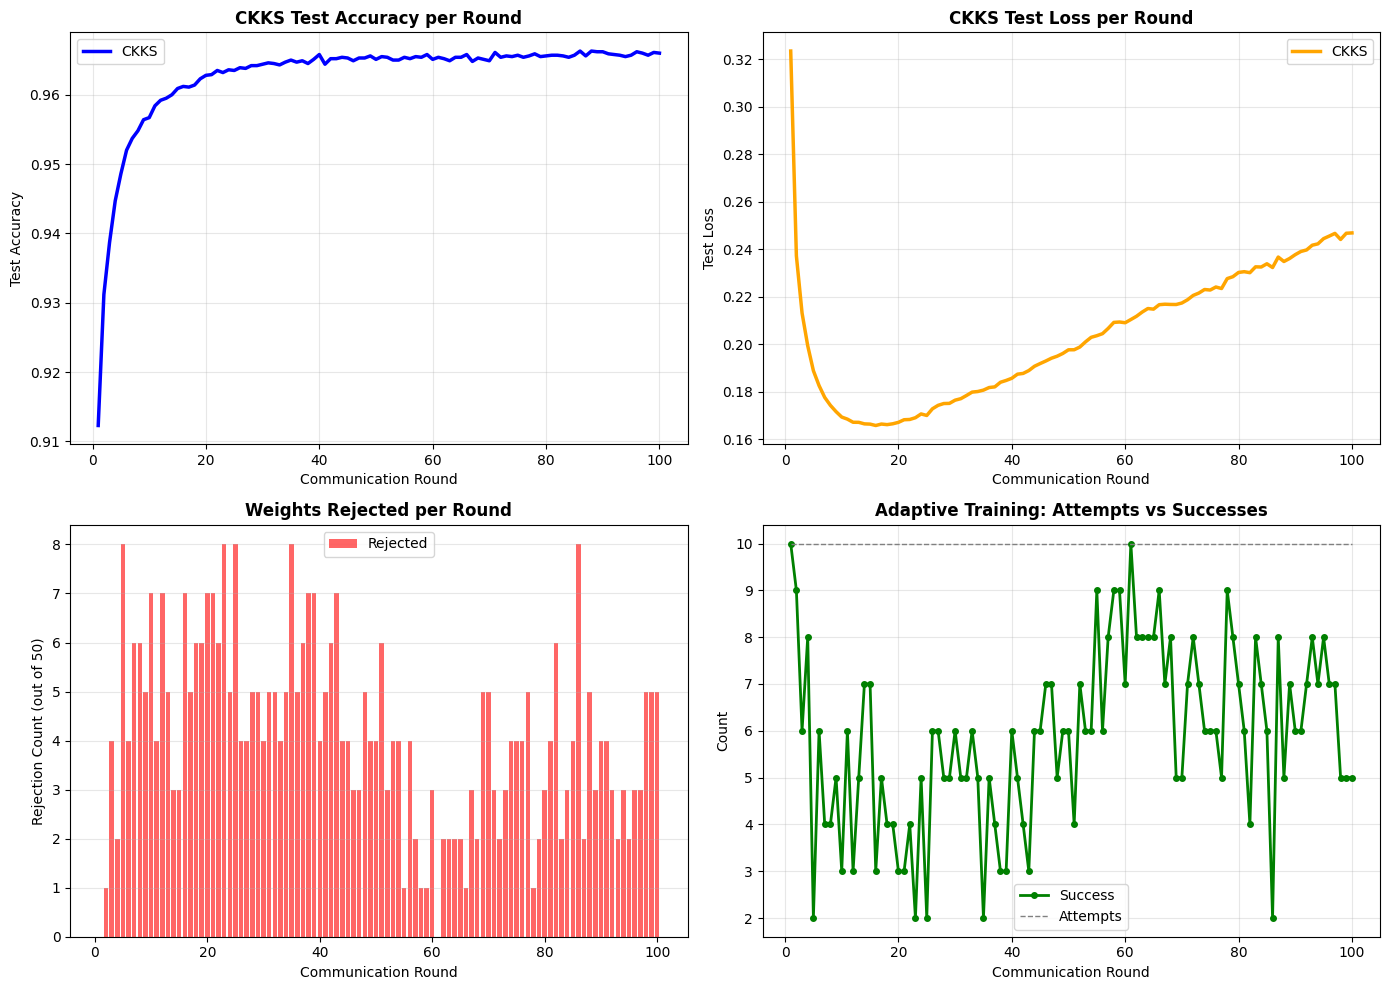

Saved plot: results_adaptive_weight_rejection_ckks_only\run_20260425_082038\ckks_results_summary.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: CKKS Test Accuracy
axes[0, 0].plot(results_df['round'], results_df['ckks_test_acc'], color='blue', linewidth=2.5, label='CKKS')
axes[0, 0].set_title('CKKS Test Accuracy per Round', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Communication Round')
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# Plot 2: CKKS Test Loss
axes[0, 1].plot(results_df['round'], results_df['ckks_test_loss'], color='orange', linewidth=2.5, label='CKKS')
axes[0, 1].set_title('CKKS Test Loss per Round', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Communication Round')
axes[0, 1].set_ylabel('Test Loss')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# Plot 3: Rejection Count per Round
axes[1, 0].bar(results_df['round'], results_df['rejected_count'], color='red', alpha=0.6, label='Rejected')
axes[1, 0].set_title('Weights Rejected per Round', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Communication Round')
axes[1, 0].set_ylabel('Rejection Count (out of 50)')
axes[1, 0].grid(alpha=0.3, axis='y')
axes[1, 0].legend()

# Plot 4: Adaptive Training Success
axes[1, 1].plot(results_df['round'], results_df['adaptive_success'], color='green', linewidth=2, marker='o', markersize=4, label='Success')
axes[1, 1].plot(results_df['round'], results_df['adaptive_attempts'], color='gray', linewidth=1, linestyle='--', label='Attempts')
axes[1, 1].set_title('Adaptive Training: Attempts vs Successes', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Communication Round')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'ckks_results_summary.png')
plt.savefig(plot_path, dpi=140, bbox_inches='tight')
plt.show()
print('Saved plot:', plot_path)


## 2) How to compare CKKS results with baseline

**This notebook stores ONLY CKKS results. You will compare manually with your baseline.**

### What this notebook saves:
- **KEY_COMPARISON_ckks_test_accuracy_50clients_100rounds.csv**: 50 clients × 100 rounds of CKKS test accuracies
- Per-client train accuracies (for reference)
- Round metrics (loss, adaptive stats, computational time)
- Final CKKS model weights

### How to compare:
1. Run your **original adaptive weight rejection notebook** (without CKKS)
2. Export its client × round test accuracy table as a CSV
3. Load both CSVs in a comparison cell (template provided in Cell 19)
4. Calculate differences (mean absolute gap between corresponding cells)

### What to look for:
- **Small differences** = CKKS encryption preserved accuracy
- **Differences < 0.001** = excellent match (encryption is transparent)
- **Differences 0.001-0.01** = acceptable (minor numerical precision loss)
- **Large differences (> 0.01)** = indicates CKKS parameter tuning may be needed

In [12]:
# OPTIONAL: Find rounds where accuracy reaches specific thresholds
print("\nACCURACY MILESTONES:")
print("=" * 80)

thresholds = [0.90, 0.92, 0.94, 0.95]
for threshold in thresholds:
    idx = np.where(results_df['ckks_test_acc'].values >= threshold)[0]
    if len(idx) > 0:
        first_round = int(results_df['round'].iloc[idx[0]])
        acc_val = results_df['ckks_test_acc'].iloc[idx[0]]
        print(f"First round with CKKS acc >= {threshold:.2f}: Round {first_round} (acc={acc_val:.4f})")
    else:
        print(f"CKKS accuracy did not reach {threshold:.2f} in 100 rounds")

print("=" * 80)



ACCURACY MILESTONES:
First round with CKKS acc >= 0.90: Round 1 (acc=0.9123)
First round with CKKS acc >= 0.92: Round 2 (acc=0.9312)
First round with CKKS acc >= 0.94: Round 4 (acc=0.9447)
First round with CKKS acc >= 0.95: Round 6 (acc=0.9520)


## 3) Notes on CKKS parameters

Important CKKS knobs and their effect:

- `poly_modulus_degree`: larger gives more security/capacity but slower compute and more memory.
- `coeff_mod_bit_sizes`: controls precision/noise budget depth.
- `global_scale`: larger scale often improves precision but can consume noise budget faster.

For this use-case (additions + division after decryption), the above defaults are usually stable. If accuracy gap grows, increase precision (for example, stronger coeff mod chain / scale tuning).

In [13]:
# CKKS Results Summary
print("\n" + "=" * 120)
print("CKKS FEDERATED LEARNING RESULTS: Summary Across All Communication Rounds")
print("=" * 120)

print("\n1. CKKS TEST ACCURACY:")
print(f"   Final CKKS Accuracy:      {results_df['ckks_test_acc'].iloc[-1]:.6f}")
print(f"   Mean CKKS Accuracy:       {results_df['ckks_test_acc'].mean():.6f}")
print(f"   Min CKKS Accuracy:        {results_df['ckks_test_acc'].min():.6f}")
print(f"   Max CKKS Accuracy:        {results_df['ckks_test_acc'].max():.6f}")

print("\n2. CKKS ACCURACY TRAJECTORY (every 10 rounds):")
for i in range(0, len(results_df), 10):
    r = results_df.iloc[i]
    print(f"   Round {int(r['round']):3d}: CKKS acc={r['ckks_test_acc']:.4f} loss={r['ckks_test_loss']:.4f}")
if (len(results_df) - 1) % 10 != 0:
    r = results_df.iloc[-1]
    print(f"   Round {int(r['round']):3d}: CKKS acc={r['ckks_test_acc']:.4f} loss={r['ckks_test_loss']:.4f}")

print("\n3. ADAPTIVE TRAINING & REJECTION STATISTICS:")
print(f"   Total Adaptive Attempts:  {results_df['adaptive_attempts'].sum():.0f}")
print(f"   Total Adaptive Success:   {results_df['adaptive_success'].sum():.0f}")
print(f"   Total Rejections:         {results_df['rejected_count'].sum():.0f}")
print(f"   Success Rate (of attempts): {100 * results_df['adaptive_success'].sum() / max(1, results_df['adaptive_attempts'].sum()):.1f}%")

print("\n4. CKKS COMPUTATIONAL OVERHEAD:")
print(f"   Mean CKKS Aggregation Time:  {results_df['ckks_aggregation_sec'].mean():.4f} sec/round")
print(f"   Mean Total Round Time:       {results_df['round_total_sec'].mean():.4f} sec/round")
print(f"   CKKS as % of Total:          {100 * results_df['ckks_aggregation_sec'].mean() / results_df['round_total_sec'].mean():.1f}%")

print("\n" + "=" * 120)



CKKS FEDERATED LEARNING RESULTS: Summary Across All Communication Rounds

1. CKKS TEST ACCURACY:
   Final CKKS Accuracy:      0.966000
   Mean CKKS Accuracy:       0.962720
   Min CKKS Accuracy:        0.912300
   Max CKKS Accuracy:        0.966300

2. CKKS ACCURACY TRAJECTORY (every 10 rounds):
   Round   1: CKKS acc=0.9123 loss=0.3234
   Round  11: CKKS acc=0.9584 loss=0.1685
   Round  21: CKKS acc=0.9629 loss=0.1682
   Round  31: CKKS acc=0.9646 loss=0.1771
   Round  41: CKKS acc=0.9644 loss=0.1874
   Round  51: CKKS acc=0.9655 loss=0.1977
   Round  61: CKKS acc=0.9654 loss=0.2104
   Round  71: CKKS acc=0.9661 loss=0.2187
   Round  81: CKKS acc=0.9657 loss=0.2305
   Round  91: CKKS acc=0.9659 loss=0.2390
   Round 100: CKKS acc=0.9660 loss=0.2468

3. ADAPTIVE TRAINING & REJECTION STATISTICS:
   Total Adaptive Attempts:  1000
   Total Adaptive Success:   587
   Total Rejections:         413
   Success Rate (of attempts): 58.7%

4. CKKS COMPUTATIONAL OVERHEAD:
   Mean CKKS Aggregation

## KEY COMPARISON FILE STRUCTURE

The primary file for comparison is:
```
KEY_COMPARISON_ckks_test_accuracy_50clients_100rounds.csv
```

**Format:**
- **Rows**: 50 clients (client_1 to client_50)
- **Columns**: 100 communication rounds (round_1 to round_100)
- **Values**: Test accuracy for each client at the end of each communication round

**To compare with your baseline:**

1. Get the baseline CSV from your previous notebook (adaptive weight rejection without CKKS)
2. Load both files:
   ```python
   baseline_df = pd.read_csv('path/to/baseline_test_accuracy_client_round_table.csv', index_col=0)
   ckks_df = pd.read_csv('KEY_COMPARISON_ckks_test_accuracy_50clients_100rounds.csv', index_col=0)
   ```
3. Compare row-wise (per-client) or column-wise (per-round)
4. Calculate differences to show encryption did not harm accuracy

In [14]:
# ============================================
# STEP 1: Export baseline from your previous notebook
# ============================================
# From your previous adaptive weight rejection notebook:
# 1. Open: federated_learning_adaptive_weight_rejection.ipynb
# 2. Run all cells until you see the client x round table
# 3. Look for the cell that saves: test_accuracy_client_round_table_100_rounds.csv
# 4. Note the file path (e.g., results_adaptive_weight_rejection_60_per_class_50_clients/)

# ============================================
# STEP 2: Compare CKKS results with baseline
# ============================================
# Once you have the baseline CSV, run this:

# Path to CKKS results (from this notebook)
ckks_file = os.path.join(RESULTS_DIR, 'KEY_COMPARISON_ckks_test_accuracy_50clients_100rounds.csv')

# Path to baseline (from your previous adaptive weight rejection notebook)
# UPDATE THIS PATH to point to your baseline file location
baseline_file = 'results_adaptive_weight_rejection_60_per_class_50_clients/test_accuracy_client_round_table_100_rounds.csv'

# Load both
try:
    ckks_df = pd.read_csv(ckks_file, index_col=0)
    baseline_df = pd.read_csv(baseline_file, index_col=0)
    
    print("✓ Loaded CKKS results:", ckks_file)
    print("✓ Loaded Baseline results:", baseline_file)
    print("\nCKKS shape:", ckks_df.shape)
    print("Baseline shape:", baseline_df.shape)
    
    print("\nCKKS first 5 clients, first 5 rounds:")
    print(ckks_df.iloc[:5, :5])
    print("\nBaseline first 5 clients, first 5 rounds:")
    print(baseline_df.iloc[:5, :5])
    
    # Calculate per-client differences
    client_diff = (ckks_df - baseline_df).abs().mean(axis=1)
    print("\n" + "=" * 80)
    print("COMPARISON RESULTS:")
    print("=" * 80)
    print("PER-CLIENT accuracy difference (mean absolute diff across all 100 rounds):")
    print(f"  Mean: {client_diff.mean():.6f}")
    print(f"  Max:  {client_diff.max():.6f}")
    print(f"  Min:  {client_diff.min():.6f}")
    
    # Calculate per-round differences
    round_diff = (ckks_df - baseline_df).abs().mean(axis=0)
    print("\nPER-ROUND accuracy difference (mean absolute diff across all 50 clients):")
    print(f"  Mean: {round_diff.mean():.6f}")
    print(f"  Max:  {round_diff.max():.6f}")
    print(f"  Min:  {round_diff.min():.6f}")
    
    print("\n" + "=" * 80)
    print("INTERPRETATION:")
    print("If differences are very small (< 0.001), CKKS encryption preserved accuracy.")
    print("=" * 80)
    
except FileNotFoundError as e:
    print("❌ File not found:", e)
    print("\nMake sure to:")
    print("1. Export the baseline CSV from your previous notebook")
    print("2. Update the 'baseline_file' path above")
    print("3. Rerun this cell")

❌ File not found: [Errno 2] No such file or directory: 'results_adaptive_weight_rejection_60_per_class_50_clients/test_accuracy_client_round_table_100_rounds.csv'

Make sure to:
1. Export the baseline CSV from your previous notebook
2. Update the 'baseline_file' path above
3. Rerun this cell


In [17]:
# Export per-client per-round test accuracies (50 clients x 100 rounds)
print("\n" + "=" * 80)
print("PER-CLIENT TEST ACCURACIES ACROSS ALL 100 COMMUNICATION ROUNDS")
print("=" * 80)

# Reload the test accuracy table (already created in Cell 10)
round_cols = [f'round_{i}' for i in range(1, NUM_ROUNDS + 1)]
client_idx = [f'client_{i}' for i in range(1, NUM_CLIENTS + 1)]

per_client_test_acc = pd.DataFrame(
    np.array(client_test_acc_history).T, 
    index=client_idx, 
    columns=round_cols
)

# This file is already saved in Cell 10, but showing it here for clarity
per_client_test_acc_path = os.path.join(RESULTS_DIR, 'KEY_COMPARISON_ckks_test_accuracy_50clients_100rounds.csv')

print(f"✓ File location: {per_client_test_acc_path}")
print(f"✓ Shape: {per_client_test_acc.shape} (50 clients × 100 rounds)")
print(f"\nFirst 5 clients, first 5 rounds:")
print(per_client_test_acc.iloc[:5, :5])
print(f"\nLast 5 clients, last 5 rounds:")
print(per_client_test_acc.iloc[-5:, -5:])
print("=" * 80)
print("This is your KEY COMPARISON FILE for manual baseline comparison.")
print("=" * 80)


PER-CLIENT TEST ACCURACIES ACROSS ALL 100 COMMUNICATION ROUNDS
✓ File location: results_adaptive_weight_rejection_ckks_only\run_20260425_082038\KEY_COMPARISON_ckks_test_accuracy_50clients_100rounds.csv
✓ Shape: (50, 100) (50 clients × 100 rounds)

First 5 clients, first 5 rounds:
          round_1  round_2  round_3  round_4  round_5
client_1   0.8909   0.9190   0.9290   0.9374   0.9417
client_2   0.8949   0.9148   0.9283   0.9355   0.9390
client_3   0.8946   0.9174   0.9301   0.9356   0.9408
client_4   0.8967   0.9184   0.9286   0.9354   0.9394
client_5   0.9021   0.9174   0.9260   0.9309   0.9364

Last 5 clients, last 5 rounds:
           round_96  round_97  round_98  round_99  round_100
client_46    0.9619    0.9600    0.9611    0.9621     0.9626
client_47    0.9632    0.9631    0.9638    0.9625     0.9633
client_48    0.9590    0.9594    0.9595    0.9600     0.9573
client_49    0.9551    0.9542    0.9568    0.9552     0.9549
client_50    0.9596    0.9592    0.9596    0.9596     0.9